# The dielectric constant and the Born charges of silicon

How the ground state **responds**: to a uniform electric field, and to an atom
being moved. The first is the high-frequency dielectric constant, which is what
a material's refractive index is made of; the second is the Born effective
charge, which is what makes an optical phonon infrared-active.

$$\varepsilon_{\infty,ij} = \delta_{ij}
   + \frac{4\pi}{\Omega}\frac{\partial P_i}{\partial E_j},
\qquad
Z^*_{a,ij} = \frac{\partial F_{a\,j}}{\partial E_i}
           = \frac{\partial^2 E}{\partial u_j\,\partial E_i}$$

The Born charge is written twice because both readings are used: it is the dipole
an atom carries when it moves, and it is the force the atom feels in a field.

On the silicon cell QE runs with `epsil = .true.`, against a re-run of the
vendored `ph.x`:

| | pypresso | `ph.x` |
|---|---|---|
| $\varepsilon_\infty$, norm-conserving Si | **13.806646** | 13.806689 |
| $\varepsilon_\infty$, **ultrasoft** Si | **14.325321** | 14.325270 |
| $\varepsilon_\infty$, **PAW** Si | **14.320211** | 14.320177 |
| $\varepsilon_\infty$, ultrasoft C | **5.756059** | 5.756182 |
| $Z^*$, norm-conserving Si | **-0.075715** | -0.07571 |
| $Z^*$, ultrasoft Si | **-0.079442** | -0.07945 |

The reference is regenerated rather than the committed one, which dates from
release 6.0 and has drifted by 3e-4, six times the disagreement being measured.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import comparison_table

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

silicon = Calculator.from_file(CASES / "si-epsilon.in", pseudo_dir=PSEUDO)
field = silicon.get_dielectric_tensor()

print("dielectric tensor, cartesian axes:")
print(np.round(field.epsilon, 6))
print(f"\ndeparture from cubic symmetry   {field.anisotropy:.1e}")

[pypresso] the dielectric tensor: no ground state cached, running the SCF first (conv_thr = 1e-12). Call get_scf() to do this explicitly.


dielectric tensor, cartesian axes:
[[13.806646  0.       -0.      ]
 [ 0.       13.806646  0.      ]
 [-0.       -0.       13.806646]]

departure from cubic symmetry   4.4e-15


The tensor came out isotropic to 4e-15 with nothing imposing that it should be.
Cubic symmetry says $\varepsilon_{ij} = \varepsilon\,\delta_{ij}$, and the three
directions were solved for independently, so the off-diagonal zeros are a
result rather than a constraint.

## Why this is a linear solve and not a sum over states

The response of a state to a perturbation is formally a sum over states,

$$ |d\psi_n\rangle = \sum_{m \neq n} |\psi_m\rangle
   \frac{\langle \psi_m | dV | \psi_n\rangle}{\varepsilon_n - \varepsilon_m}, $$

which needs every empty band and divides by a gap that closes at every
degeneracy, and a crystal is degenerate everywhere by symmetry. Written instead
as a linear system,

$$ (H - \varepsilon_n S + \alpha Q)\,|d\psi_n\rangle
   = -P_c^{+}\, dV\, |\psi_n\rangle, $$

it needs no empty states at all and never divides by
$\varepsilon_n - \varepsilon_m$. One projected conjugate-gradient solve per
occupied band gives the first-order wavefunction, and the density response
follows from it.

A uniform field is the one perturbation a periodic code cannot simply write
down: $V = \mathbf E \cdot \mathbf r$ is neither bounded nor lattice periodic.
What is well defined is $P_c\,\mathbf r|\psi\rangle$, reached through the
commutator $[H, \mathbf r]$. The induced charge then screens the field and the
response has to be solved self-consistently with it, which is what makes
$\varepsilon_\infty$ a number near 14 rather than a small first-order shift.

That commutator is worth asking for on its own. In the periodic gauge
$\partial H(k)/\partial k_a = i[H, r_a]$, so the same object that builds the
field perturbation is the **velocity operator**, and applied to a band it gives
the group velocity $\hbar \mathbf v_n = \nabla_{\mathbf k}\varepsilon_{n\mathbf k}$
that a transport calculation integrates. For a *local* potential it would just
be $\mathbf k + \mathbf G$; a pseudopotential is nonlocal, and leaving that
part out is worth percent-level errors in any optical quantity.

In [2]:
velocities = silicon.get_band_velocities()

speeds = np.linalg.norm(np.asarray(velocities.velocities), axis=-1)
print(f"band velocities, one vector per band per k-point: {speeds.shape}")
print(f"largest group velocity   {speeds.max():.4f} Ry bohr")
print(f"smallest                 {speeds.min():.4f} Ry bohr")

band velocities, one vector per band per k-point: (10, 4)
largest group velocity   1.2857 Ry bohr
smallest                 0.1890 Ry bohr


Nothing there was differenced: each number is an expectation value of an
operator, evaluated at the k-points the self-consistent run already used. None
of them is small, and that is a property of the grid rather than of the crystal:
a Monkhorst-Pack grid is deliberately shifted off the high-symmetry points, and
those are exactly where $d\varepsilon/dk$ vanishes. Asking for the velocity
along a path through $\Gamma$ (`get_band_velocities(kpoints=path)`) puts the
zeros back.

The overlap operator carries the same $\mathbf k$ the Hamiltonian does, so on
an ultrasoft dataset a band velocity is the *generalised* Hellmann-Feynman
derivative and $dS/dk$ is part of it: identically zero for a norm-conserving
dataset, and 1.5e-2 for an ultrasoft one.

In [3]:
# The charges are the response to the same field, so this reuses the solve above
# rather than running a second one.
born = silicon.get_born_charges()

print(comparison_table(
    [("epsilon (nc)", field.isotropic, 13.806689470),
     ("Z* Si 1", float(born[0, 0, 0]), -0.07571),
     ("Z* Si 2", float(born[1, 0, 0]), -0.07571)],
    fmt="{:.6f}", headers=("", "pypresso", "ph.x", "difference")))

               pypresso       ph.x  difference
epsilon (nc)  13.806646  13.806689     4.3e-05
Z* Si 1       -0.075715  -0.075710     5.0e-06
Z* Si 2       -0.075715  -0.075710     5.0e-06


Silicon's Born effective charge is **zero by symmetry** in a fully converged
calculation, so the $-0.0757$ above is a residue: a valence charge of 4 against
an electronic part near 4.076. Reproducing it to every digit `ph.x` prints is a
sharper test than the dielectric constant, because a difference of two large
numbers has to come out small in the same way in both codes.

## The charge that does the screening

This is the physics behind $\varepsilon_\infty = 13.8$ rather than 1. Averaging
the induced density over the two directions perpendicular to the field is exact
in reciprocal space and leaves a function of $x$ alone.

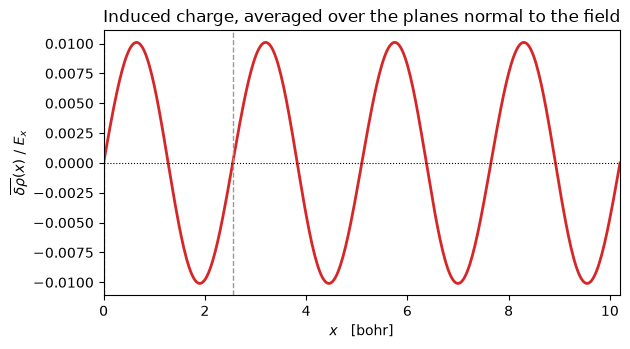

In [4]:
from pypresso.basis.fft import r_to_g               # no facade route to rho(G)

system = silicon.system
dense = silicon.calculation.basis.dense
g = np.asarray(dense.cartesian(system.cell))
along_x = (np.abs(g[:, 1]) < 1e-8) & (np.abs(g[:, 2]) < 1e-8)
induced = np.asarray(r_to_g(field.induced_density[0, 0], dense.fft_index))

alat = float(system.cell.alat)
x = np.linspace(0.0, alat, 400)
profile = np.real(induced[along_x] @ np.exp(1j * np.outer(x, g[along_x, 0])).T)

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(x, profile, color="C3", lw=2.0)
ax.axhline(0.0, color="k", lw=0.8, ls=":")
for atom in np.asarray(system.structure.positions)[:, 0] % alat:
    ax.axvline(atom, color="0.6", lw=1.0, ls="--")
ax.set_xlabel("$x$   [bohr]")
ax.set_ylabel(r"$\overline{\delta\rho}(x)\ /\ E_x$")
ax.set_title("Induced charge, averaged over the planes normal to the field")
ax.set_xlim(0.0, alat)
fig.tight_layout()

The dashed line is one of the two silicon atoms; the other sits at $x = 0$, on
the left edge of the plot. The induced charge vanishes on both and is extremal
between them: the field pushes charge off one side of every bond
and onto the other, and the dipole that makes is what screens it. That the
profile is very nearly a single sinusoid says the response along $x$ is
dominated by the shortest reciprocal-lattice vector in that direction, which is
what makes silicon a simple dielectric.

## Ultrasoft, where the density is not $|\psi|^2$

On a norm-conserving dataset the electron density is $|\psi|^2$. On an ultrasoft
one it is not: part of the charge lives inside the augmentation spheres, and it
responds to the perturbation along with everything else. Every layer of the
response gains a term because of it, and the dielectric constant is the check
that all of them are there.

In [5]:
ultrasoft = Calculator.from_file(CASES / "si-epsilon-us.in", pseudo_dir=PSEUDO)
us = ultrasoft.get_dielectric_tensor()

print(comparison_table(
    [("epsilon (ultrasoft)", us.isotropic, 14.325270),
     ("Z* (ultrasoft)", float(ultrasoft.get_born_charges()[0, 0, 0]), -0.07945)],
    fmt="{:.6f}", headers=("", "pypresso", "ph.x", "difference")))

[pypresso] the dielectric tensor: no ground state cached, running the SCF first (conv_thr = 1e-12). Call get_scf() to do this explicitly.


                      pypresso       ph.x  difference
epsilon (ultrasoft)  14.325321  14.325270     5.1e-05
Z* (ultrasoft)       -0.079442  -0.079450     8.3e-06


Leaving the augmentation charge's own share out of the Born charge gives
**+0.1625** on this cell: wrong in sign as well as in size, which is why it is
the quantity that says whether every term is present. Two more cases are
measured the same way and quoted rather than run here, because each costs a
self-consistent response of its own: **PAW silicon** gives 14.320211 against
`ph.x`'s 14.320177, and **ultrasoft carbon**, a different element at a different
cutoff and lattice constant, gives 5.756059 against 5.756182.

Two spin channels work as well. Their $\chi_0$ is block diagonal in spin, so
each channel responds on its own, and the check that catches a factor of two in
the spin sum is not a reference at all: silicon's $\varepsilon_\infty$ run as
`nspin = 1` and as `nspin = 2` with no magnetization comes out **13.806646105
both ways, 6.2e-14 apart**.

## What it refuses

**A response has a direction and must be symmetrised as a polar vector**, not as
three independent scalars. On a symmetry-reduced k-set the point group has to
put back what the reduction took out, and getting that wrong is worth
percent-level errors. The obvious escape, running the whole k-grid, works only
if the grid is closed under the point group, and **a shifted Monkhorst-Pack grid
is not**: 2304 of the 3072 rotation images of a shifted $4\times4\times4$ grid on
fcc silicon land off it. Run anyway, this cell gives a 2% asymmetric density and
off-diagonal entries of **3.77 that cubic symmetry forbids**, all of it looking
like a working calculation. That combination is refused by name. An unshifted
grid is closed exactly, and there the escape does work.

Also refused by name: **PAW Born charges**, at 1.3e-3 with the missing term
identified rather than fitted; noncollinear magnetism, DFT+U and spin spirals in
the response; a potential-only meta-GGA; a fixed occupation that cuts a
**degenerate multiplet**, where which member falls below the cut is arbitrary and
the response depends on that choice; and the *screened* response of a magnetic
system with vacuum, because the LSDA kernel diverges wherever a channel density
reaches zero.

---
The tests behind this notebook: `tests/regression/test_response.py`,
`tests/regression/test_lsda_response.py`.